<a href="https://colab.research.google.com/github/MonishaPandhi/IB2AD0_Data_Science_GenerativeAI/blob/main/Copy_of_Wk_7_Seminar_EDA_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/EDA-DP.csv')
display(df.head())

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


I have imported the dataset and examined the first 5 rows to see where I can draw insights from. I have decided that I want to analyse salary in usd by experience and job type.

In [ ]:
# Define the mapping for experience levels
experience_level_mapping = {
    'EN': 0, # Entry-level
    'MI': 1, # Mid-level
    'SE': 2, # Senior-level
    'EX': 3  # Executive-level
}

# Apply the mapping to the 'experience_level' column in the main DataFrame (df)
df['experience_level_numeric'] = df['experience_level'].map(experience_level_mapping)

# Display the first few rows of the main DataFrame with the new numerical column
display(df[['experience_level', 'experience_level_numeric']].head())

,experience_level,experience_level_numeric
0,SE,2
1,SE,2
2,SE,2
3,SE,2
4,SE,2


I have converted the different experience levels into boolean values to later perform group statistical analysis alongside salary in usd. Python recognises boolean more effectively as categories.

In [ ]:
display(df.head())

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_numeric
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M,2
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M,2
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M,2
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M,2
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


I wanted to know more about the data hence I have sought out this information. It wasn't so useful as it simply showed there are 16534 employees and the columns are either objects or integers.

In [ ]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,16534.000000,1.653400e+04,16534.000000,16534.000000
mean,2023.226866,1.637270e+05,149686.777973,32.003750
std,0.713558,3.402057e+05,68505.293156,46.245158
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.017630e+05,101125.000000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.872000e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


I aimed to seek more information here as well to understand the data better but I did not gain many insights.

In [ ]:
df_experience_salary = df[['experience_level_numeric', 'job_title', 'salary_in_usd']]
display(df_experience_salary.head())

,experience_level_numeric,job_title,salary_in_usd
0,2,AI Engineer,202730
1,2,AI Engineer,92118
2,2,Data Engineer,130500
3,2,Data Engineer,96000
4,2,Machine Learning Engineer,190000


I decided to create a subset with the numeric experience level, job title and salary in USD to explore how salary differs by experience and job type.

In [ ]:
df_experience_salary.isnull().sum()

,0
experience_level,0
job_title,0
salary_in_usd,0
experience_level_numeric,0


Luckily, there are no null values.

In [ ]:
salary_data = df_experience_salary['salary_in_usd']

# Mean, Median, Mode
mean_salary = salary_data.mean()
median_salary = salary_data.median()
mode_salary = salary_data.mode().to_list()

# Range
max_salary = salary_data.max()
min_salary = salary_data.min()
range_salary = max_salary - min_salary

# Skewness and Kurtosis
skewness = salary_data.skew()
kurtosis = salary_data.kurt()

# Outliers (using IQR method)
Q1 = salary_data.quantile(0.25)
Q3 = salary_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = salary_data[(salary_data < lower_bound) | (salary_data > upper_bound)]

# Percentiles
percentiles = salary_data.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

print(f"Mean Salary in USD: {mean_salary:.2f}")
print(f"Median Salary in USD: {median_salary:.2f}")
print(f"Mode Salary in USD: {mode_salary}")
print(f"Range of Salary in USD: {range_salary:.2f} (Min: {min_salary:.2f}, Max: {max_salary:.2f})")
print(f"Skewness of Salary in USD: {skewness:.2f}")
print(f"Kurtosis of Salary in USD: {kurtosis:.2f}")
print(f"Number of Outliers in Salary in USD: {len(outliers)}")
print(f"Percentiles of Salary in USD:\n{percentiles}")

Mean Salary in USD: 149686.78
Median Salary in USD: 141300.00
Mode Salary in USD: [150000]
Range of Salary in USD: 785000.00 (Min: 15000.00, Max: 800000.00)
Skewness of Salary in USD: 1.49
Kurtosis of Salary in USD: 7.62
Number of Outliers in Salary in USD: 283
Percentiles of Salary in USD:
0.05     55395.3
0.25    101125.0
0.50    141300.0
0.75    185900.0
0.95    265000.0
Name: salary_in_usd, dtype: float64


The mean is higher than the median hence salary in usd is skewed positively. The kurtosis value confirms this as it's leptokurtic suggesting that most people make towards the lower end of salaries and around the mean level. However, there are several outliers which will need to be consulted with a subject matter expert on.

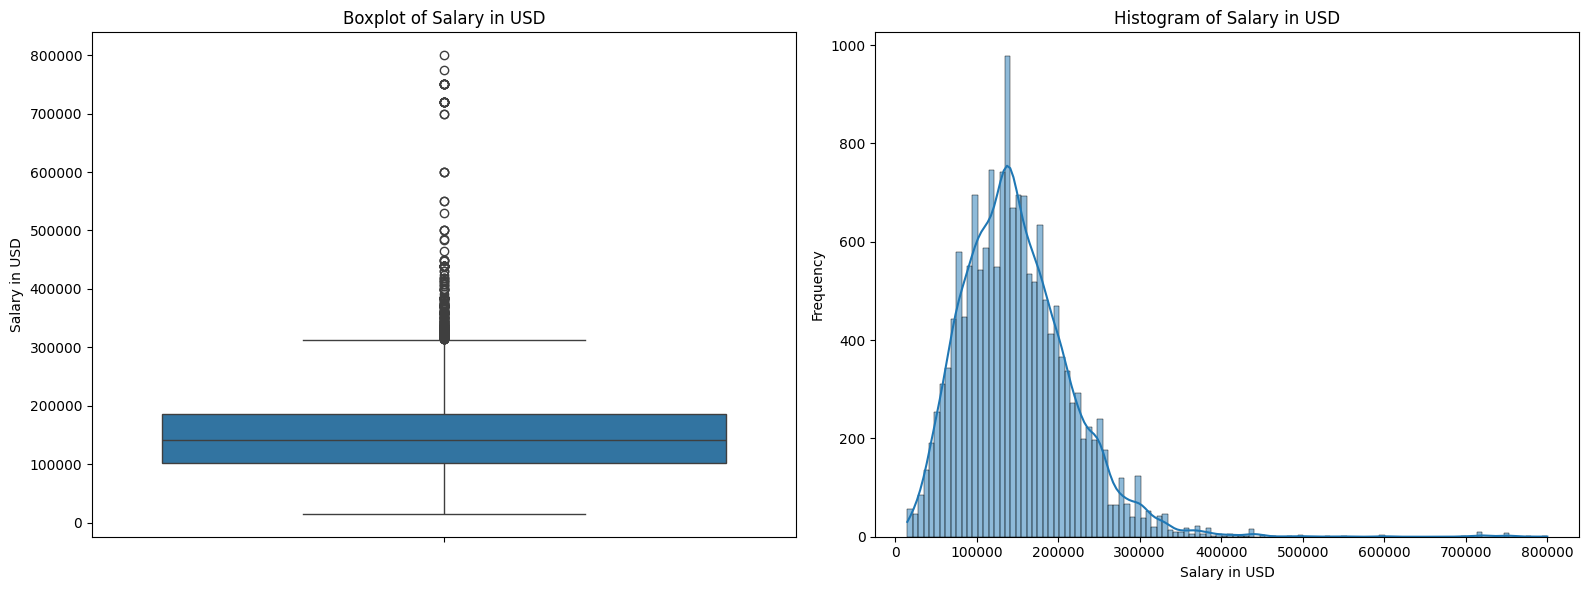

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# Boxplot for salary_in_usd
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df_experience_salary['salary_in_usd'])
plt.title('Boxplot of Salary in USD')
plt.ylabel('Salary in USD')

# Histogram for salary_in_usd
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_experience_salary['salary_in_usd'], kde=True)
plt.title('Histogram of Salary in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The boxplot and histogram confirm the above where we can see most people making around the mean value. Very few make it past $300000 USD.

In [ ]:
display(df_experience_salary.head(20))

,experience_level_numeric,job_title,salary_in_usd
0,2,AI Engineer,202730
1,2,AI Engineer,92118
2,2,Data Engineer,130500
3,2,Data Engineer,96000
4,2,Machine Learning Engineer,190000
5,2,Machine Learning Engineer,160000
6,1,ML Engineer,400000
7,1,ML Engineer,65000
8,0,Data Analyst,101520
9,0,Data Analyst,45864


In [ ]:
# Group by 'experience_level_numeric' and calculate descriptive statistics for 'salary_in_usd'

# Calculate Q1 and Q3 for IQR
Q1 = df_experience_salary.groupby('experience_level_numeric')['salary_in_usd'].quantile(0.25)
Q3 = df_experience_salary.groupby('experience_level_numeric')['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

# Calculate mean, median, and standard deviation
mean_salary_by_experience = df_experience_salary.groupby('experience_level_numeric')['salary_in_usd'].mean()
median_salary_by_experience = df_experience_salary.groupby('experience_level_numeric')['salary_in_usd'].median()
std_dev_salary_by_experience = df_experience_salary.groupby('experience_level_numeric')['salary_in_usd'].std()

# Combine the results into a single DataFrame for better readability
summary_stats_by_experience = pd.DataFrame({
    'Mean Salary (USD)': mean_salary_by_experience,
    'Median Salary (USD)': median_salary_by_experience,
    'Standard Deviation (USD)': std_dev_salary_by_experience,
    'IQR (USD)': IQR
})

display(summary_stats_by_experience)

,Mean Salary (USD),Median Salary (USD),Standard Deviation (USD),IQR (USD)
experience_level_numeric,,,,
0,92327.413585,83000.0,51838.624747,58000.0
1,125923.131253,115000.0,67067.615240,74018.0
2,163662.826148,155000.0,63948.402646,80000.0
3,195264.281437,192000.0,70398.699827,91000.0


I want to examine the salary in usd by experience level so I calculate the mean, median, standard deviation and interquartile range for each category. As experience level increases, so do these values suggesting it is likely that as experience level increases so does salary level. Since the standard deviation and interquartile range also increase with experience level, it suggests the spread of salaries is higher as you earn more. Hence, there's more variability between those of a higher experience level in the company.

In [ ]:
# Calculate the Pearson correlation coefficient
correlation = df_experience_salary['experience_level_numeric'].corr(df_experience_salary['salary_in_usd'])

print(f"Pearson Correlation between Experience Level (Numeric) and Salary in USD: {correlation:.2f}")

Pearson Correlation between Experience Level (Numeric) and Salary in USD: 0.35


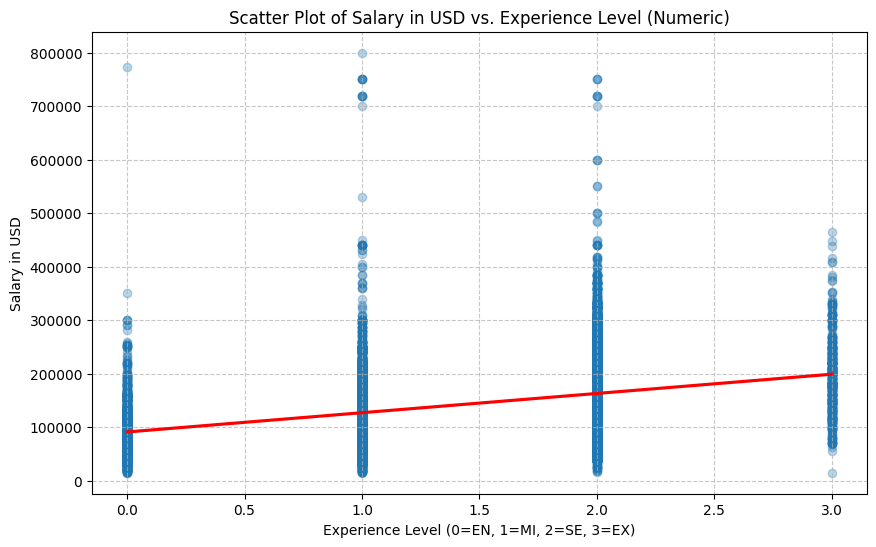

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='experience_level_numeric', y='salary_in_usd', data=df_experience_salary,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Salary in USD vs. Experience Level (Numeric)')
plt.xlabel('Experience Level (0=EN, 1=MI, 2=SE, 3=EX)')
plt.ylabel('Salary in USD')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatterplot confirms the above with a postive correlation shown between experience level and salary in usd.

In [ ]:
grouped_salary_stats = df_experience_salary.groupby(['experience_level_numeric', 'job_title'])['salary_in_usd'].agg([
    'mean',
    'median',
    'std',
    'count'
]).rename(columns={
    'mean': 'Mean Salary (USD)',
    'median': 'Median Salary (USD)',
    'std': 'Standard Deviation (USD)',
    'count': 'Number of Employees'
})

display(grouped_salary_stats.head(10)) # Displaying first 10 combinations for brevity
print(f"\nTotal unique combinations of Experience Level and Job Title: {len(grouped_salary_stats)}")

Mean Salary (USD)  \
experience_level_numeric job_title                                   
0                        AI Developer                    110119.50   
                         AI Engineer                      33679.00   
                         AI Programmer                    56858.80   
                         AI Research Engineer             28734.00   
                         AI Research Scientist            88888.00   
                         AI Scientist                     60911.50   
                         AI Software Engineer            117647.00   
                         Admin & Data Analyst             50000.00   
                         Analytics Engineer              100935.25   
                         Applied Data Scientist           51945.60   

                                                 Median Salary (USD)  \
experience_level_numeric job_title                                     
0                        AI Developer                       100000.0   
                         AI Engineer                         35000.0   
                         AI Programmer                       60207.0   
                         AI Research Engineer                24940.0   
                         AI Research Scientist               88888.0   
                         AI Scientist                        38708.0   
                         AI Software Engineer               117647.0   
                         Admin & Data Analyst                50000.0   
                         Analytics Engineer                 110750.0   
                         Applied Data Scientist              40000.0   

                                                 Standard Deviation (USD)  \
experience_level_numeric job_title                                          
0                        AI Developer                        60443.541219   
                         AI Engineer                         11482.631711   
                         AI Programmer                       16195.298166   
                         AI Research Engineer                 7113.319057   
                         AI Research Scientist                        NaN   
                         AI Scientist                        69375.210315   
                         AI Software Engineer                         NaN   
                         Admin & Data Analyst                         NaN   
                         Analytics Engineer                  37358.674931   
                         Applied Data Scientist              33533.453644   

                                                 Number of Employees  
experience_level_numeric job_title                                    
0                        AI Developer                              6  
                         AI Engineer                               3  
                         AI Programmer                             5  
                         AI Research Engineer                      3  
                         AI Research Scientist                     1  
                         AI Scientist                              6  
                         AI Software Engineer                      1  
                         Admin & Data Analyst                      1  
                         Analytics Engineer                       12  
                         Applied Data Scientist                    5


Total unique combinations of Experience Level and Job Title: 349


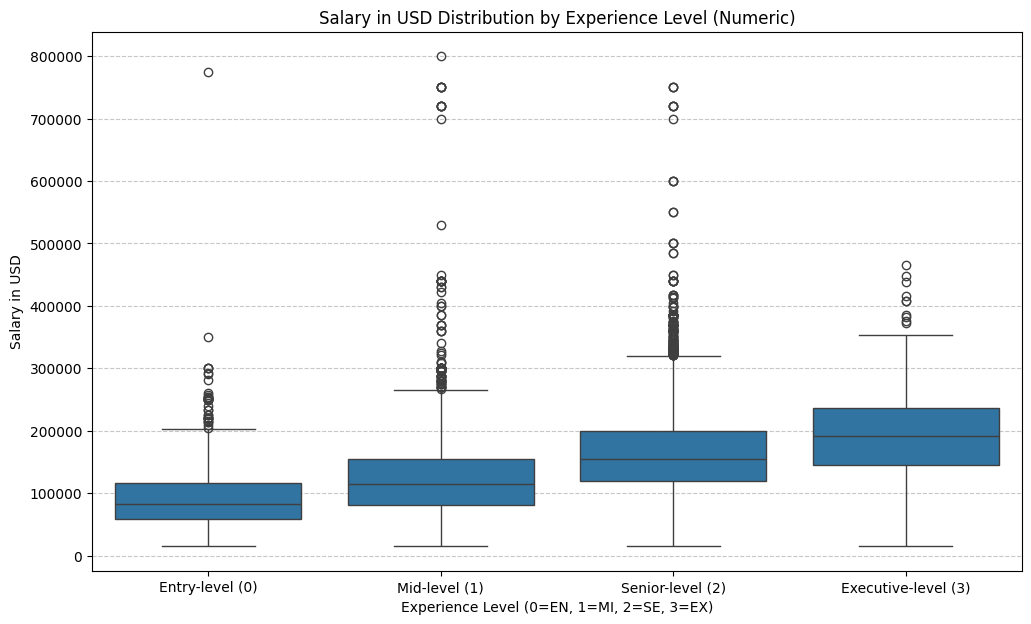

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='experience_level_numeric', y='salary_in_usd', data=df_experience_salary)
plt.title('Salary in USD Distribution by Experience Level (Numeric)')
plt.xlabel('Experience Level (0=EN, 1=MI, 2=SE, 3=EX)')
plt.ylabel('Salary in USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Entry-level (0)', 'Mid-level (1)', 'Senior-level (2)', 'Executive-level (3)'])
plt.show()


In [ ]:
top_5_highest_paying_job_titles = df_experience_salary.groupby('job_title')['salary_in_usd'].median().nlargest(5)

print("Top 5 Highest Paying Job Titles (based on average salary in USD):")
display(top_5_highest_paying_job_titles.reset_index())

Top 5 Highest Paying Job Titles (based on average salary in USD):


,job_title,salary_in_usd
0,Analytics Engineering Manager,399880.0
1,Data Science Tech Lead,375000.0
2,Head of Machine Learning,330000.0
3,Managing Director Data Science,280000.0
4,AWS Data Architect,258000.0


In [ ]:
experience_level_labels = {
    0: 'Entry-level (EN)',
    1: 'Mid-level (MI)',
    2: 'Senior-level (SE)',
    3: 'Executive-level (EX)'
}

print("Top 5 Highest Paying Job Titles by Experience Level (based on average salary in USD):\n")

for level_numeric, level_label in experience_level_labels.items():
    print(f"--- {level_label} ---")
    # Filter the grouped stats for the current experience level
    level_data = grouped_salary_stats.loc[level_numeric]

    # Sort by 'Mean Salary (USD)' and get the top 5
    top_5_jobs_for_level = level_data.sort_values(by='Mean Salary (USD)', ascending=False).head(5)
    display(top_5_jobs_for_level[['Mean Salary (USD)']])
    print("\n")

Top 5 Highest Paying Job Titles by Experience Level (based on average salary in USD):

--- Entry-level (EN) ---


,Mean Salary (USD)
job_title,
Research Scientist,165070.486486
Applied Scientist,153442.857143
Business Intelligence Lead,150747.500000
Machine Learning Operations Engineer,150000.000000
Cloud Data Engineer,138588.500000




--- Mid-level (MI) ---


,Mean Salary (USD)
job_title,
AI Architect,800000.000000
AWS Data Architect,258000.000000
Machine Learning Scientist,233893.333333
Data Infrastructure Engineer,217288.750000
Director of Data Science,204500.000000




--- Senior-level (SE) ---


,Mean Salary (USD)
job_title,
Analytics Engineering Manager,399880.000000
Data Science Tech Lead,375000.000000
Deep Learning Engineer,272374.000000
Cloud Data Architect,250000.000000
AI Architect,233631.481481




--- Executive-level (EX) ---


,Mean Salary (USD)
job_title,
Principal Data Scientist,416000.000000
Head of Machine Learning,299758.428571
Managing Director Data Science,280000.000000
Machine Learning Engineer,235030.555556
Director of Data Science,230673.285714


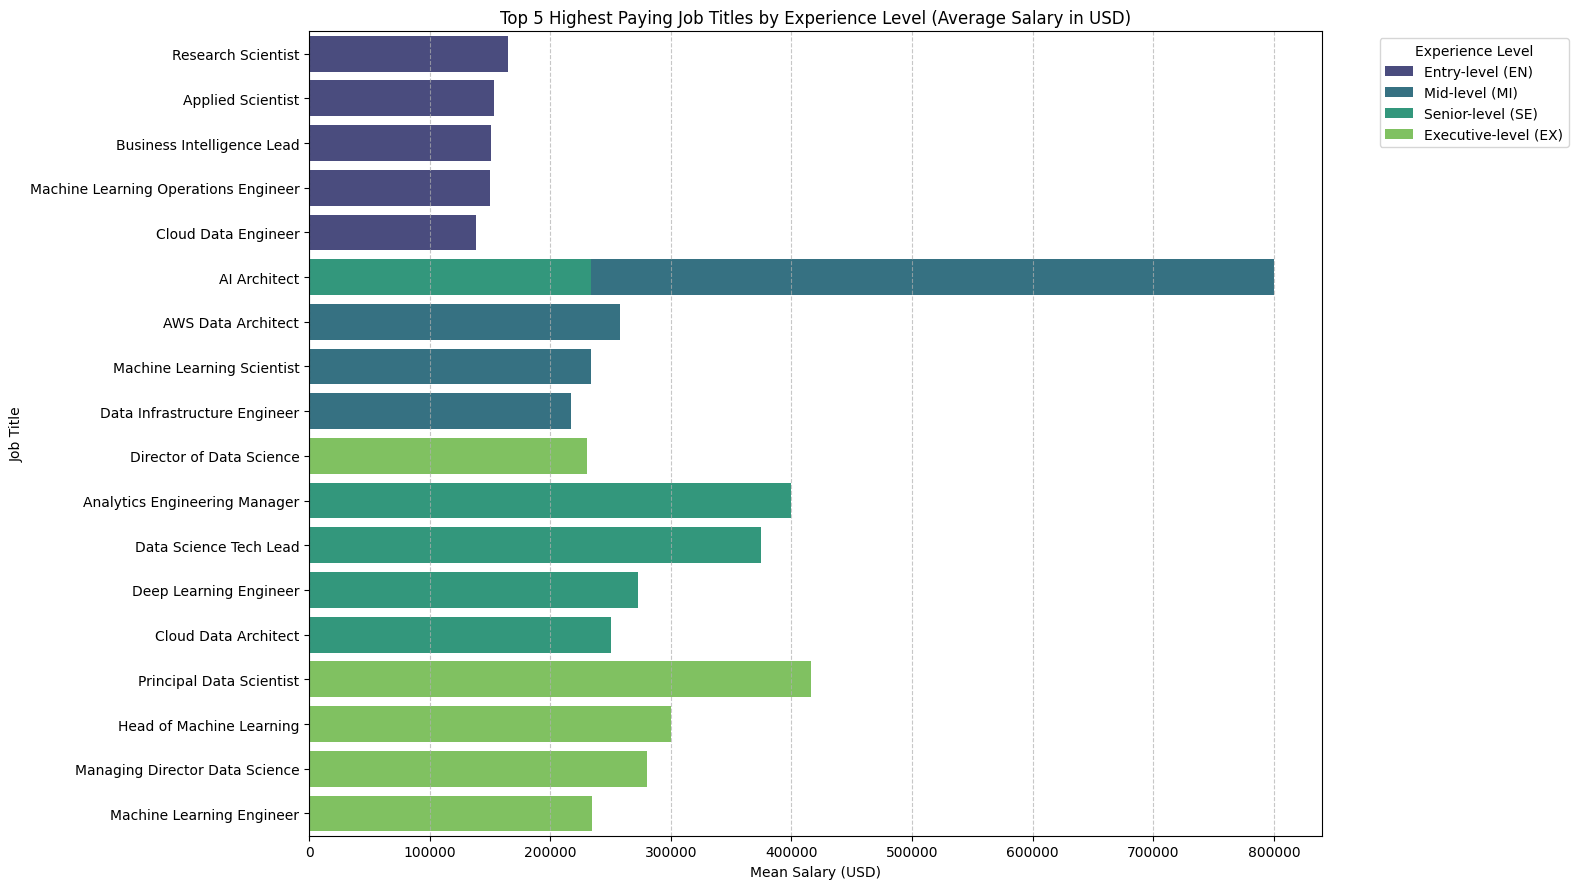

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_data = []
for level_numeric, level_label in experience_level_labels.items():
    level_data = grouped_salary_stats.loc[level_numeric]
    top_5_jobs_for_level = level_data.sort_values(by='Mean Salary (USD)', ascending=False).head(5).reset_index()
    top_5_jobs_for_level['experience_level_label'] = level_label
    plot_data.append(top_5_jobs_for_level)

all_top_jobs_df = pd.concat(plot_data)

# Create the grouped bar plot
plt.figure(figsize=(16, 9))
sns.barplot(x='Mean Salary (USD)', y='job_title', hue='experience_level_label', data=all_top_jobs_df,
            palette='viridis', dodge=False)

plt.title('Top 5 Highest Paying Job Titles by Experience Level (Average Salary in USD)')
plt.xlabel('Mean Salary (USD)')
plt.ylabel('Job Title')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

I decided to examine the top 5 highest paid roles by experience level since there's so many different kinds of roles. I plotted it on a group bar chart. From this, we can conclude an AI architect gets paid the most despite being a mid-level role.

In [ ]:
print("Top 5 Lowest Paying Job Titles by Experience Level (based on average salary in USD):\n")

for level_numeric, level_label in experience_level_labels.items():
    print(f"--- {level_label} ---")
    # Filter the grouped stats for the current experience level
    level_data = grouped_salary_stats.loc[level_numeric]

    # Sort by 'Mean Salary (USD)' in ascending order and get the top 5
    top_5_lowest_jobs_for_level = level_data.sort_values(by='Mean Salary (USD)', ascending=True).head(5)
    display(top_5_lowest_jobs_for_level[['Mean Salary (USD)']])
    print("\n")

Top 5 Lowest Paying Job Titles by Experience Level (based on average salary in USD):

--- Entry-level (EN) ---


,Mean Salary (USD)
job_title,
Data Analyst Lead,18000.0
Data Analytics Engineer,20000.0
Data Quality Engineer,23753.0
Data Analytics Manager,27000.0
AI Research Engineer,28734.0




--- Mid-level (MI) ---


,Mean Salary (USD)
job_title,
AI Programmer,30000.0
Head of Data,31520.0
Big Data Engineer,35361.4
NLP Engineer,45733.0
Lead Data Analyst,46493.0




--- Senior-level (SE) ---


,Mean Salary (USD)
job_title,
Data Integration Specialist,36483.0
Principal Data Architect,38154.0
CRM Data Analyst,40000.0
Computer Vision Software Engineer,53984.0
Data DevOps Engineer,53984.0




--- Executive-level (EX) ---


,Mean Salary (USD)
job_title,
Staff Data Analyst,15000.000000
Data Science Consultant,69741.000000
Data Manager,89297.600000
Data Analyst,112572.916667
Lead Data Engineer,115222.000000


**Reasoning**:
To visually represent the top 5 lowest paying job titles by experience level, I will create a grouped bar plot using the data prepared from the previous step. This will provide a clear comparison across different experience levels.



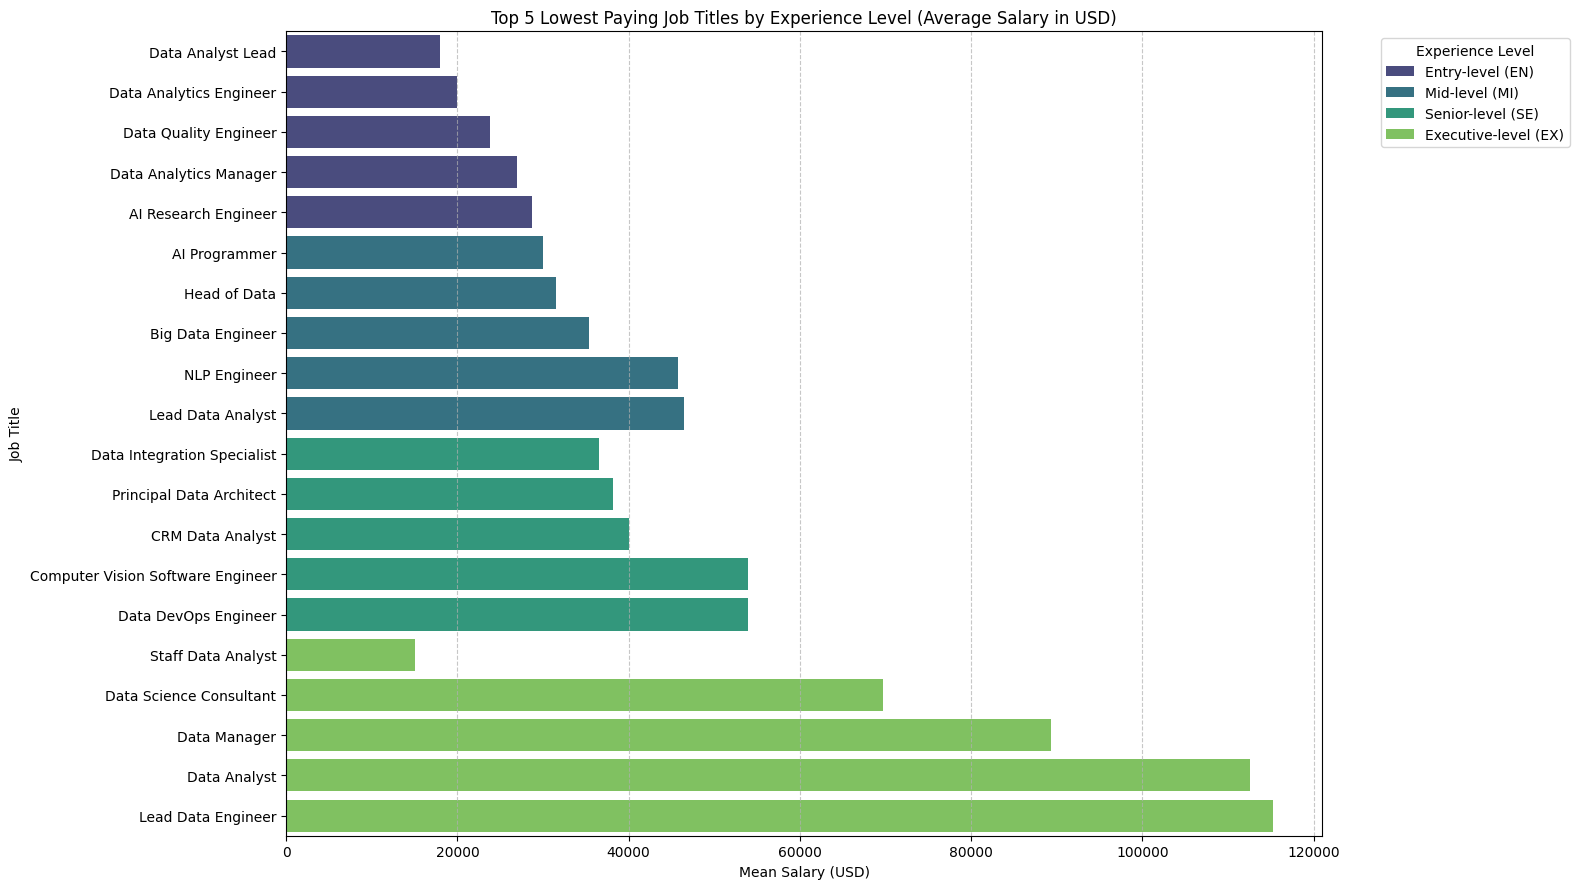

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_data_lowest = []
for level_numeric, level_label in experience_level_labels.items():
    level_data = grouped_salary_stats.loc[level_numeric]
    top_5_lowest_jobs_for_level = level_data.sort_values(by='Mean Salary (USD)', ascending=True).head(5).reset_index()
    top_5_lowest_jobs_for_level['experience_level_label'] = level_label
    plot_data_lowest.append(top_5_lowest_jobs_for_level)

all_lowest_jobs_df = pd.concat(plot_data_lowest)

# Create the grouped bar plot
plt.figure(figsize=(16, 9))
sns.barplot(x='Mean Salary (USD)', y='job_title', hue='experience_level_label', data=all_lowest_jobs_df,
            palette='viridis', dodge=False)

plt.title('Top 5 Lowest Paying Job Titles by Experience Level (Average Salary in USD)')
plt.xlabel('Mean Salary (USD)')
plt.ylabel('Job Title')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

I decided to examine the bottom 5 lowest paid roles by experience level since there's so many different kinds of roles. I plotted it on a group bar chart. From this, we can conclude an executive level staff data analyst gets paid the least despite being an executive role.